# 04 · Comparación Argentina vs. Global

Comparación entre series (autocorrelación y correlación cruzada).

In [6]:
import sys
sys.path.append("..")

from src import utils

En este notebook se comparan las series temporales de **“Tusa”** en Argentina y a nivel Global. El objetivo es analizar si el comportamiento local y global de la canción presenta patrones similares, tanto en el dominio del tiempo como mediante herramientas como autocorrelación y correlación cruzada.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RUTA = "../data/charts_ar_global.csv"

df = pd.read_csv(RUTA, parse_dates=["date"])
df.head()

,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,I Want You Back,142,2017-01-01,The Jackson 5,https://open.spotify.com/track/3b0EOvScbZUc0qJ...,Global,top200,MOVE_UP,436184.0
2,Thinking out Loud,141,2017-01-01,Ed Sheeran,https://open.spotify.com/track/1Slwb6dOYkBlWal...,Global,top200,SAME_POSITION,436476.0
3,Lighthouse - Andrelli Remix,140,2017-01-01,Hearts & Colors,https://open.spotify.com/track/04CttTezSnv71US...,Global,top200,MOVE_DOWN,439245.0
4,Me llamas (feat. Maluma) - Remix,139,2017-01-01,Piso 21,https://open.spotify.com/track/5hEM0JchdVzQ5Pw...,Global,top200,MOVE_UP,439910.0


In [8]:
df["region"].value_counts()

region
Argentina    455308
Global       451793
Name: count, dtype: int64

El dataset cargado contiene observaciones tanto para **Argentina** como para **Global**, por lo que permite construir y comparar dos series temporales para la misma canción. La cantidad de registros es similar en ambas regiones, lo que facilita el análisis comparativo.

In [9]:
CANCION = "Tusa"
ARTISTA = "KAROL G, Nicki Minaj"

df_tusa = df[
    (df["title"] == CANCION) &
    (df["artist"] == ARTISTA) &
    (df["chart"] == "top200")
].sort_values(["region", "date"]).copy()

df_tusa[["date", "region", "title", "artist", "rank", "streams"]].head()

,date,region,title,artist,rank,streams
519235,2019-11-11,Argentina,Tusa,"KAROL G, Nicki Minaj",182,29708.0
519795,2019-11-12,Argentina,Tusa,"KAROL G, Nicki Minaj",154,33750.0
520175,2019-11-13,Argentina,Tusa,"KAROL G, Nicki Minaj",126,36935.0
520632,2019-11-14,Argentina,Tusa,"KAROL G, Nicki Minaj",114,41342.0
521340,2019-11-15,Argentina,Tusa,"KAROL G, Nicki Minaj",74,60945.0


In [10]:
df_tusa["region"].value_counts()

region
Argentina    566
Global       501
Name: count, dtype: int64

La canción seleccionada aparece tanto en Argentina como en Global dentro del chart `top200`. Esto confirma que se pueden construir dos series temporales comparables para analizar similitudes y diferencias entre el comportamiento local y el comportamiento global.

Construimos dos series temporales de streams diarios para la misma canción: una correspondiente a Argentina y otra correspondiente al chart Global. Ambas series tienen frecuencia diaria y permiten comparar la evolución local y global de la canción.

In [11]:
serie_arg = utils.construir_serie(
    df,
    {
        "title": CANCION,
        "artist": ARTISTA,
        "region": "Argentina",
        "chart": "top200",
        "valor": "streams",
        "agregado": "sum"
    }
)

serie_global = utils.construir_serie(
    df,
    {
        "title": CANCION,
        "artist": ARTISTA,
        "region": "Global",
        "chart": "top200",
        "valor": "streams",
        "agregado": "sum"
    }
)

print(f"Muestras Argentina: {len(serie_arg)}")
print(f"Muestras Global: {len(serie_global)}")
print(f"Argentina: {serie_arg.index.min().date()} a {serie_arg.index.max().date()}")
print(f"Global: {serie_global.index.min().date()} a {serie_global.index.max().date()}")

Muestras Argentina: 566
Muestras Global: 501
Argentina: 2019-11-11 a 2021-07-24
Global: 2019-11-08 a 2021-03-29


Las series de Argentina y Global no cubren exactamente el mismo período: la serie global comienza unos días antes, mientras que la serie argentina continúa durante más tiempo. Para realizar una comparación justa entre ambas, se trabajará con el intervalo temporal común.

In [12]:
fecha_inicio_comun = max(serie_arg.index.min(), serie_global.index.min())
fecha_fin_comun = min(serie_arg.index.max(), serie_global.index.max())

serie_arg_comun = serie_arg.loc[fecha_inicio_comun:fecha_fin_comun]
serie_global_comun = serie_global.loc[fecha_inicio_comun:fecha_fin_comun]

print(f"Inicio común: {fecha_inicio_comun.date()}")
print(f"Fin común: {fecha_fin_comun.date()}")
print(f"Muestras Argentina período común: {len(serie_arg_comun)}")
print(f"Muestras Global período común: {len(serie_global_comun)}")

Inicio común: 2019-11-11
Fin común: 2021-03-29
Muestras Argentina período común: 505
Muestras Global período común: 498


In [13]:
df_comparacion = pd.concat(
    [serie_arg_comun, serie_global_comun],
    axis=1
)

df_comparacion.columns = ["Argentina", "Global"]

df_comparacion = df_comparacion.dropna()

print(f"Muestras comparables: {len(df_comparacion)}")
print(f"Inicio comparable: {df_comparacion.index.min().date()}")
print(f"Fin comparable: {df_comparacion.index.max().date()}")

df_comparacion.head()

Muestras comparables: 498
Inicio comparable: 2019-11-11
Fin comparable: 2021-03-29


,Argentina,Global
date,,
2019-11-11,29708.0,977948.0
2019-11-12,33750.0,1048830.0
2019-11-13,36935.0,1127798.0
2019-11-14,41342.0,1193841.0
2019-11-15,60945.0,1493872.0


Luego de alinear ambas series por fecha y eliminar los días sin datos en alguna de las dos regiones, quedaron **498 observaciones comparables** entre el 11 de noviembre de 2019 y el 29 de marzo de 2021. A partir de este punto, todas las comparaciones se realizan sobre fechas presentes en ambas series.

Como la cantidad de streams globales es mucho mayor que la cantidad de streams en Argentina, se normalizan ambas series para poder comparar sus formas. La normalización permite observar si las curvas tienen patrones similares de crecimiento, pico y caída, independientemente de la escala.

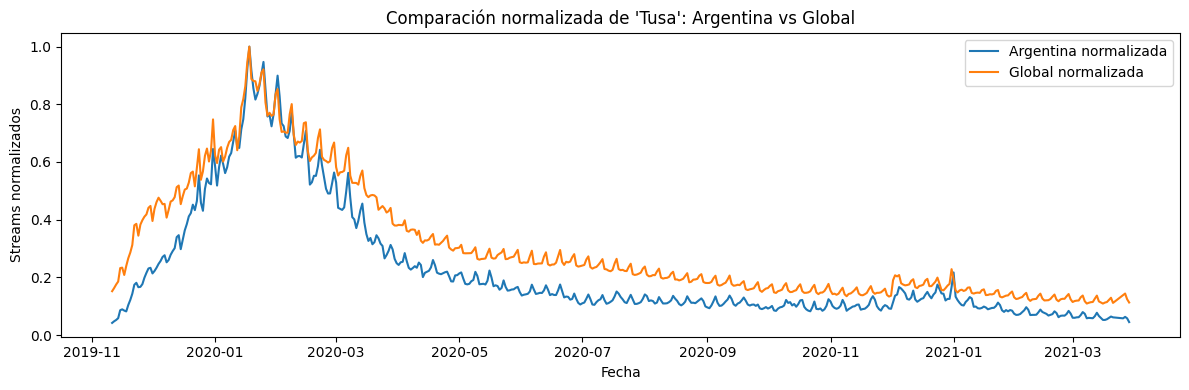

In [14]:
df_norm = df_comparacion / df_comparacion.max()

plt.figure(figsize=(12, 4))
plt.plot(df_norm.index, df_norm["Argentina"], label="Argentina normalizada")
plt.plot(df_norm.index, df_norm["Global"], label="Global normalizada")
plt.title("Comparación normalizada de 'Tusa': Argentina vs Global")
plt.xlabel("Fecha")
plt.ylabel("Streams normalizados")
plt.legend()
plt.tight_layout()
plt.show()

Al normalizar las series, se puede comparar la forma de evolución de la canción en Argentina y Global sin que la diferencia de escala o cantidad total de streams distorsione el gráfico. Esta comparación permite observar si ambas regiones presentan un ciclo de vida similar: crecimiento inicial, pico de popularidad y posterior caída.

In [15]:
correlacion = df_norm["Argentina"].corr(df_norm["Global"])

print(f"Correlación Argentina vs Global: {correlacion:.4f}")

Correlación Argentina vs Global: 0.9746


La correlación entre las series normalizadas de Argentina y Global es **0.9746**, un valor muy cercano a 1. Esto indica una asociación lineal positiva muy fuerte entre ambas curvas: cuando la popularidad global de la canción aumenta o disminuye, en Argentina tiende a ocurrir un comportamiento similar. Esto sugiere que el ciclo de vida local de “Tusa” está fuertemente alineado con su comportamiento global.

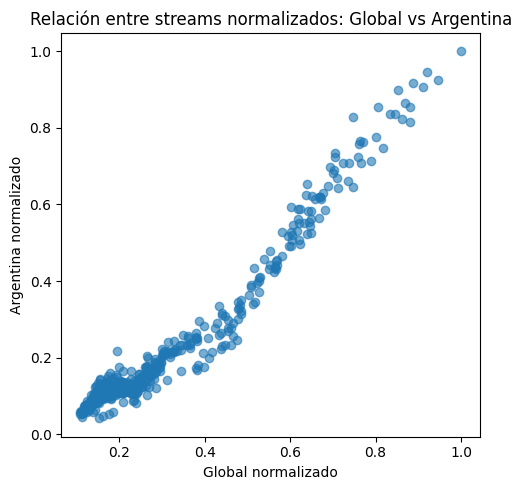

In [16]:
plt.figure(figsize=(5, 5))
plt.scatter(df_norm["Global"], df_norm["Argentina"], alpha=0.6)
plt.title("Relación entre streams normalizados: Global vs Argentina")
plt.xlabel("Global normalizado")
plt.ylabel("Argentina normalizado")
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra una relación positiva clara entre ambas series normalizadas. Los puntos se concentran alrededor de una tendencia creciente, lo cual es coherente con la correlación alta calculada anteriormente. Esto indica que las variaciones de la popularidad global y argentina de la canción siguen patrones muy similares.

La correlación cruzada permite comparar dos series temporales considerando distintos desplazamientos temporales o lags. En este caso, se busca analizar si el comportamiento de “Tusa” en Argentina ocurre al mismo tiempo que el comportamiento global, o si una de las series parece adelantarse respecto de la otra.

In [17]:
cc_tusa = utils.correlacion_cruzada(
    df_norm["Argentina"],
    df_norm["Global"],
    max_lag=30
)

cc_tusa.head()

-30    0.752753
-29    0.769811
-28    0.781430
-27    0.785673
-26    0.793449
Name: correlacion_cruzada, dtype: float64

In [19]:
lag_max = cc_tusa.idxmax()
corr_max = cc_tusa.max()

print(f"Lag de máxima correlación: {lag_max} días")
print(f"Correlación máxima: {corr_max:.4f}")

Lag de máxima correlación: 0 días
Correlación máxima: 0.9746


La correlación cruzada alcanza su valor máximo en **lag 0**, con una correlación de **0.9746**. Esto indica que, dentro del período comparable, el comportamiento de “Tusa” en Argentina y en Global está alineado temporalmente: no se observa un retraso o adelanto relevante de una serie respecto de la otra. En otras palabras, los cambios principales en la popularidad de la canción ocurren aproximadamente al mismo tiempo en ambas regiones.

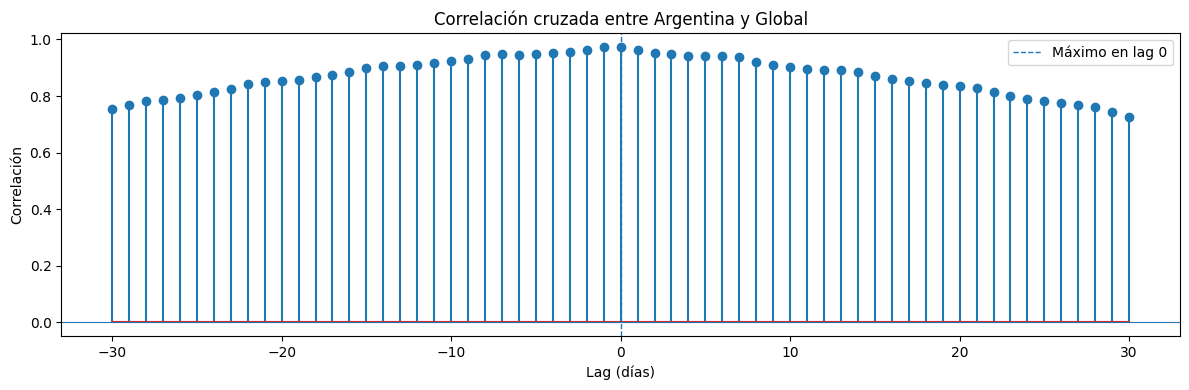

In [20]:
plt.figure(figsize=(12, 4))
plt.stem(cc_tusa.index, cc_tusa.values)
plt.axvline(lag_max, linestyle="--", linewidth=1, label=f"Máximo en lag {lag_max}")
plt.axhline(0, linewidth=0.8)
plt.title("Correlación cruzada entre Argentina y Global")
plt.xlabel("Lag (días)")
plt.ylabel("Correlación")
plt.legend()
plt.tight_layout()
plt.show()

El gráfico de correlación cruzada muestra visualmente que el máximo se alcanza en el lag 0. Esto confirma que la similitud entre las series es mayor cuando se comparan las observaciones del mismo día. Por lo tanto, no se identifica un desfase temporal importante entre Argentina y Global para esta canción.

In [21]:
fecha_pico_arg = df_comparacion["Argentina"].idxmax()
valor_pico_arg = df_comparacion["Argentina"].max()

fecha_pico_global = df_comparacion["Global"].idxmax()
valor_pico_global = df_comparacion["Global"].max()

print(f"Pico Argentina: {valor_pico_arg:,.0f} streams el {fecha_pico_arg.date()}")
print(f"Pico Global: {valor_pico_global:,.0f} streams el {fecha_pico_global.date()}")
print(f"Diferencia entre picos: {(fecha_pico_arg - fecha_pico_global).days} días")

Pico Argentina: 708,411 streams el 2020-01-18
Pico Global: 6,437,662 streams el 2020-01-18
Diferencia entre picos: 0 días


El pico máximo de streams ocurre el mismo día en ambas series: el **18 de enero de 2020**. En Argentina, el máximo fue de **708.411 streams**, mientras que en Global fue de **6.437.662 streams**. Aunque la escala global es mucho mayor, la coincidencia temporal de los picos confirma que el momento de máxima popularidad de la canción estuvo alineado entre Argentina y el comportamiento global.

En este notebook se comparó el comportamiento de **“Tusa”** en Argentina y a nivel Global, tratándola como dos series temporales de streams diarios. Como las escalas de ambas series son muy diferentes, se trabajó con series normalizadas para poder comparar sus formas.

La comparación visual mostró que Argentina y Global presentan ciclos de vida muy similares. Esto fue confirmado por una correlación simple de **0.9746**, lo que indica una asociación positiva muy fuerte entre ambas curvas. Además, la correlación cruzada alcanzó su máximo en **lag 0**, con el mismo valor de **0.9746**, lo que sugiere que no hay un desfase temporal importante entre las dos series.

También se observó que el pico máximo de popularidad ocurrió el mismo día en ambas regiones, el **18 de enero de 2020**. En conjunto, estos resultados indican que el comportamiento local de “Tusa” en Argentina estuvo fuertemente alineado con su comportamiento global, tanto en forma como en timing.